In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from datasets import Dataset

# Load the parquet file using Hugging Face's native reader
hf_dataset = Dataset.from_parquet("train_data.parquet")

# Convert it safely to a Pandas DataFrame
df_train = hf_dataset.to_pandas()

df_train.head()

d:\swiggy\swigenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26


In [8]:
df_train.shape

(36467, 20)

In [9]:
df_train.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='str')

In [10]:
df_train.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1501
Delivery_person_Ratings        1547
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1401
Time_Order_picked                 0
Weather_conditions              493
Road_traffic_density            482
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             790
Festival                        192
City                            957
Time_taken (min)                  0
dtype: int64

In [11]:
df_train.duplicated().sum()

np.int64(0)

In [12]:
df_train.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,34966.000000,34920.000000,36467.000000,36467.000000,36467.000000,36467.000000,36467.000000,35677.000000,36467.000000
mean,29.570840,4.635049,17.018788,70.232339,17.477175,70.865342,1.023528,0.744121,26.293772
std,5.806952,0.331905,8.211851,22.924137,7.339140,21.100321,0.839533,0.571962,9.384628
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170283,12.989096,73.288921,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.004377,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.046106,22.785049,78.110820,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [13]:
df_train.sample(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
30798,0x7381,COIMBRES05DEL02,30.0,5.0,11.022169,76.999594,11.072169,77.049594,13-03-2022,17:50,17:55,Fog,Medium,0,Drinks,motorcycle,0.0,No,Metropolitian,25
31165,0xbebf,RANCHIRES09DEL03,38.0,4.9,23.351058,85.325731,23.411058,85.385731,28-03-2022,22:25,22:40,Sunny,Low,2,Snack,scooter,1.0,No,Metropolitian,10
10093,0x328e,BANGRES11DEL01,36.0,4.3,12.934365,77.616155,13.004365,77.686155,16-03-2022,17:45,17:55,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,31
25473,0x69ae,PUNERES14DEL02,26.0,4.7,18.516216,73.842527,18.646216,73.972527,25-03-2022,23:30,23:45,Sandstorms,Low,1,Meal,motorcycle,1.0,No,Metropolitian,12
1973,0x3dfa,JAPRES13DEL02,34.0,4.3,26.846156,75.802300,26.896156,75.852300,05-04-2022,20:20,20:35,Fog,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,31
1667,0xb9ad,PUNERES06DEL02,36.0,4.9,18.546258,73.904337,18.596258,73.954337,05-04-2022,17:55,18:05,Sandstorms,Medium,2,Buffet,electric_scooter,1.0,No,Metropolitian,26
29234,0x1e0d,CHENRES04DEL01,26.0,4.7,13.029780,80.208812,13.099780,80.278812,25-03-2022,22:10,22:25,Sandstorms,Low,2,Drinks,scooter,1.0,No,Metropolitian,14
28691,0x4d46,RANCHIRES17DEL02,31.0,4.8,23.374878,85.335739,23.394878,85.355739,01-03-2022,10:50,0.458333333,Sandstorms,Low,1,Snack,scooter,1.0,No,Metropolitian,23
26647,0x80ad,PUNERES14DEL01,22.0,4.9,18.516216,73.842527,18.556216,73.882527,24-03-2022,0.625,15:10,Stormy,High,0,Buffet,motorcycle,0.0,No,Metropolitian,37
9666,0xdd2f,BHPRES03DEL01,20.0,4.7,23.214294,77.435361,23.254294,77.475361,17-02-2022,13:45,0.583333333,Sunny,High,1,Drinks,scooter,1.0,No,Urban,12


### Missing Values

In [14]:
df_train.loc[3927]["Delivery_person_Ratings"]

np.float64(nan)

In [15]:
df_train.replace('NaN', np.nan, inplace=True)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36462,0x348c,CHENRES12DEL01,39.0,4.7,12.972793,80.249982,13.042793,80.319982,02-03-2022,22:45,22:55,Stormy,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,27
36463,0x6d1c,JAPRES01DEL01,37.0,4.8,26.905190,75.810753,26.945190,75.850753,15-03-2022,15:50,0.666666667,Stormy,Medium,1,Buffet,scooter,0.0,No,Metropolitian,26
36464,0x17ab,RANCHIRES08DEL02,30.0,4.2,23.353783,85.326967,23.483783,85.456967,04-03-2022,21:15,21:20,Stormy,Jam,2,Drinks,scooter,2.0,No,Metropolitian,37
36465,0x59a,INDORES08DEL03,NaN,NaN,-22.725748,75.898497,22.755747,75.928497,21-03-2022,NaN,22:05,Stormy,Jam,1,Buffet,scooter,1.0,No,Metropolitian,16


converting all the string null values into Null in the **Weather condition** column

In [16]:
(
  df_train.loc[:,"Weather_conditions"].str.replace("conditions","").replace("NaN",np.nan)
  .isna().sum()
)

np.int64(493)

In [17]:
df_train.isna().sum() 

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1501
Delivery_person_Ratings        1547
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1401
Time_Order_picked                 0
Weather_conditions              493
Road_traffic_density            482
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             790
Festival                        192
City                            957
Time_taken (min)                  0
dtype: int64

In [18]:
missing_df = (
  df_train.replace("NaN",np.nan)
  .assign(
    Weather_conditions = lambda df_train_:(
    df_train_["Weather_conditions"]
    .str.replace("conditions","")
    .replace("NaN",np.nan)
    )
  )
)

In [19]:
missing_df = df_train.isnull().sum()
missing_df

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1501
Delivery_person_Ratings        1547
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1401
Time_Order_picked                 0
Weather_conditions              493
Road_traffic_density            482
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             790
Festival                        192
City                            957
Time_taken (min)                  0
dtype: int64

<Axes: >

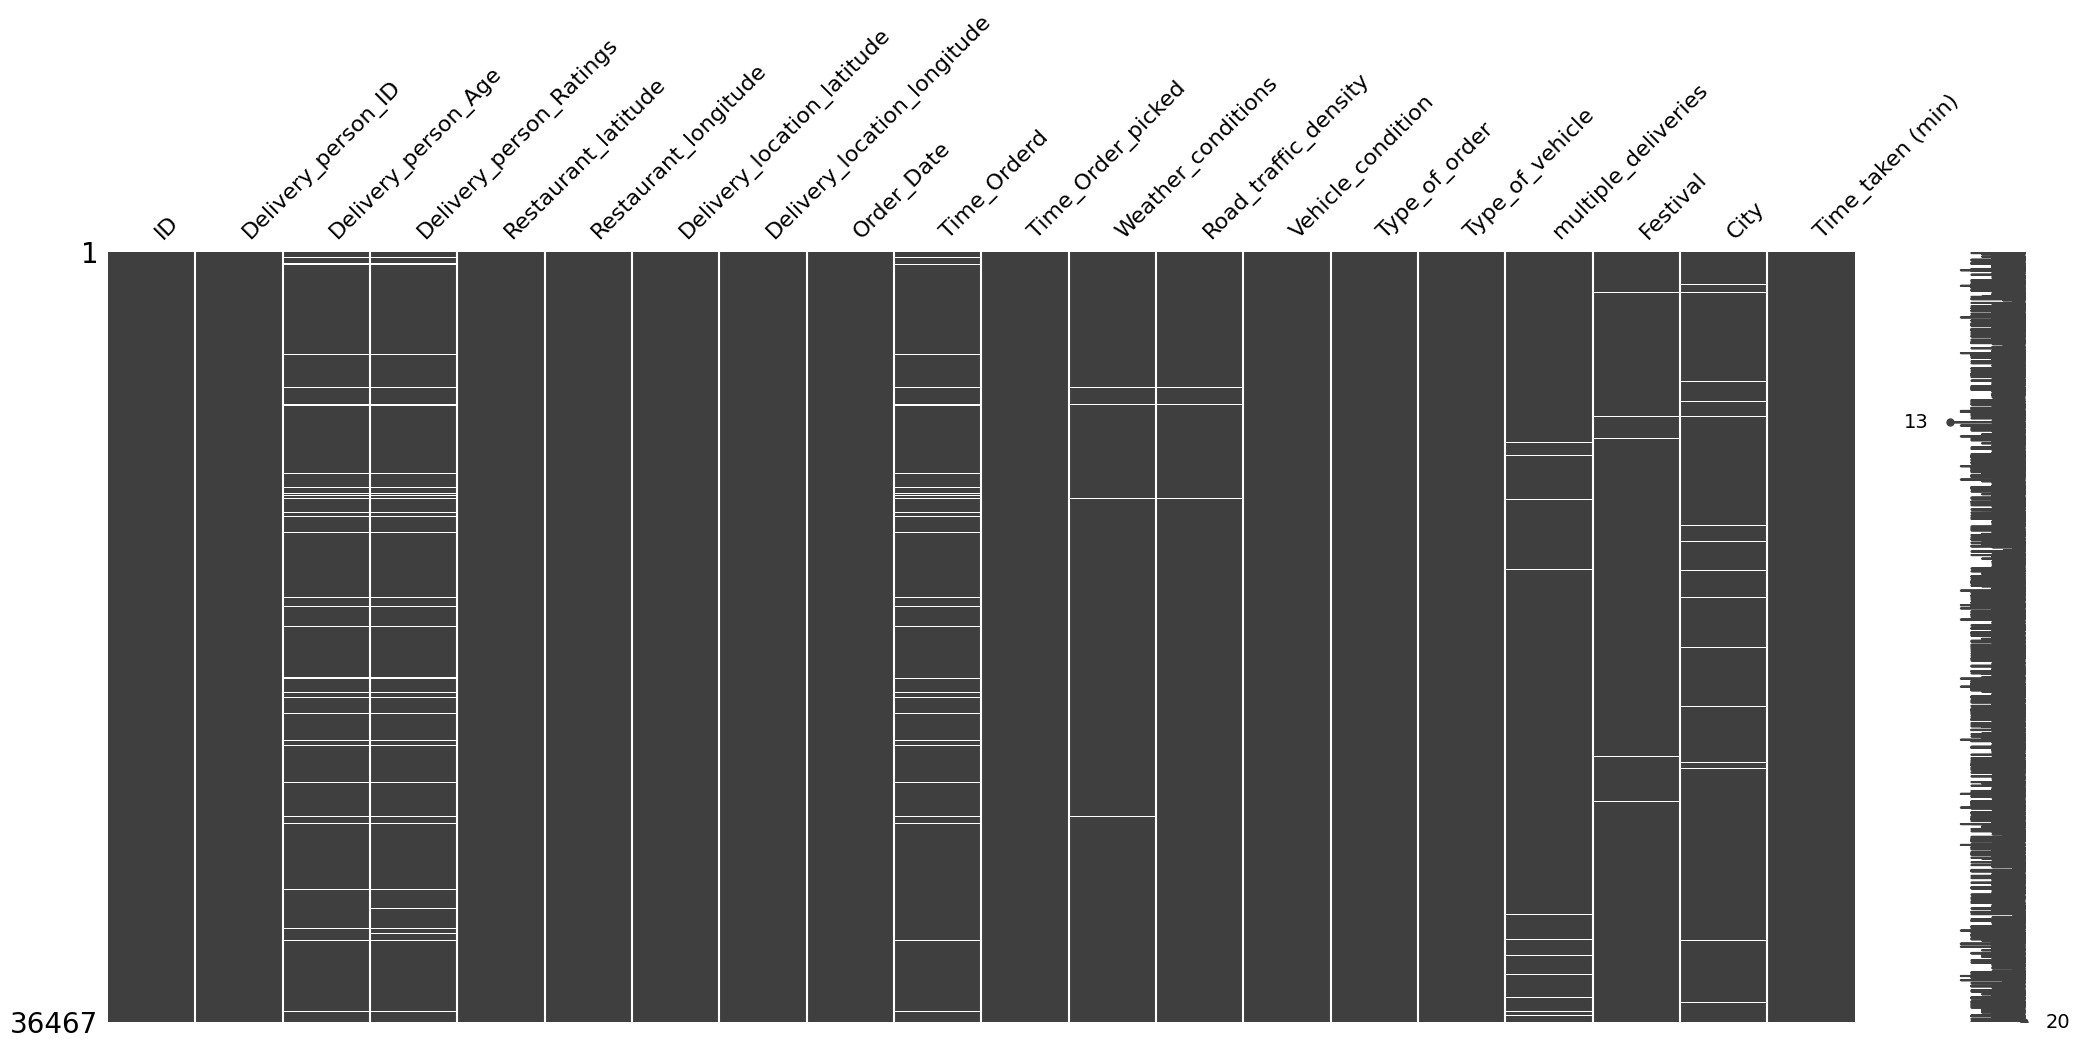

In [20]:
import missingno as msno
msno.matrix(df_train)

<Axes: >

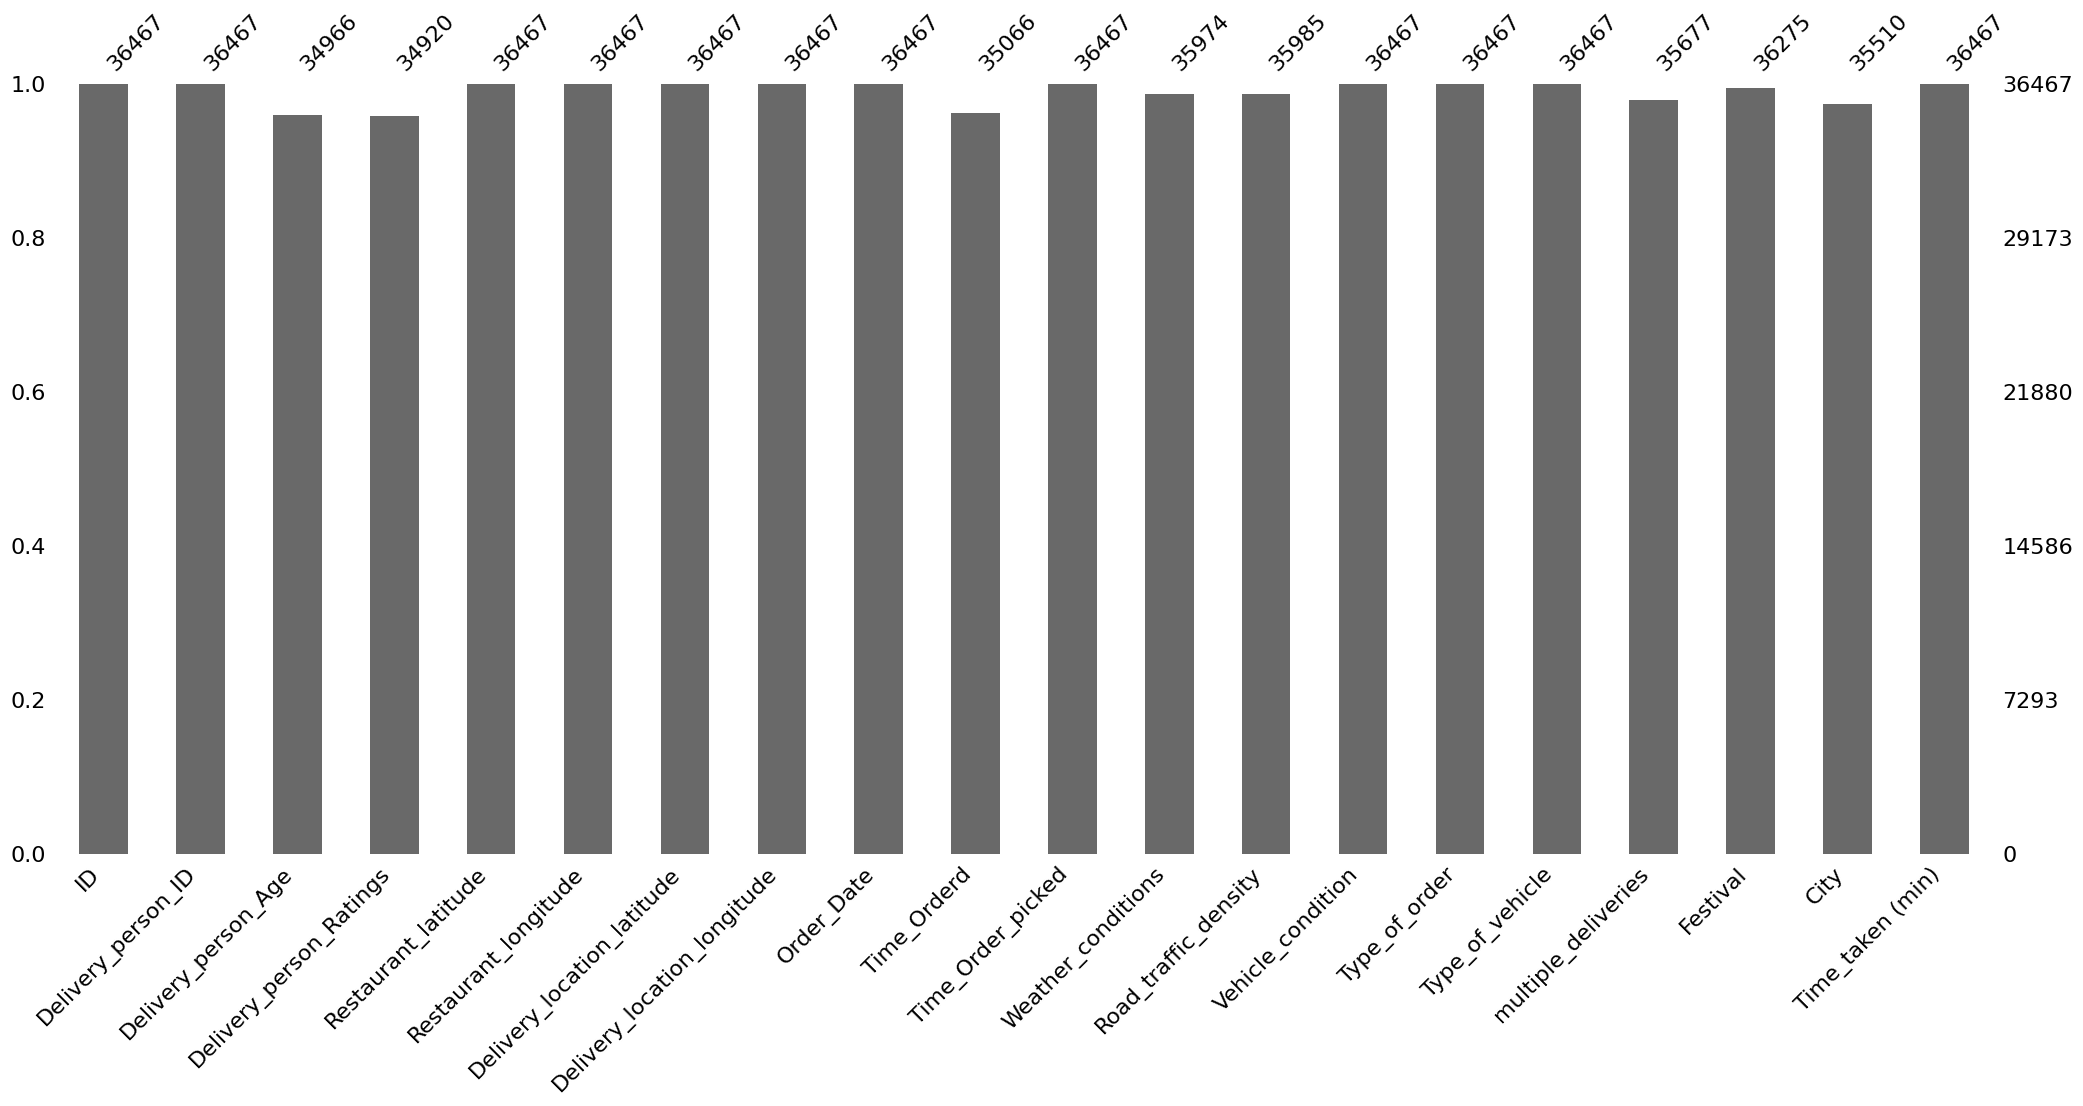

In [21]:
msno.bar(df_train)

<Axes: >

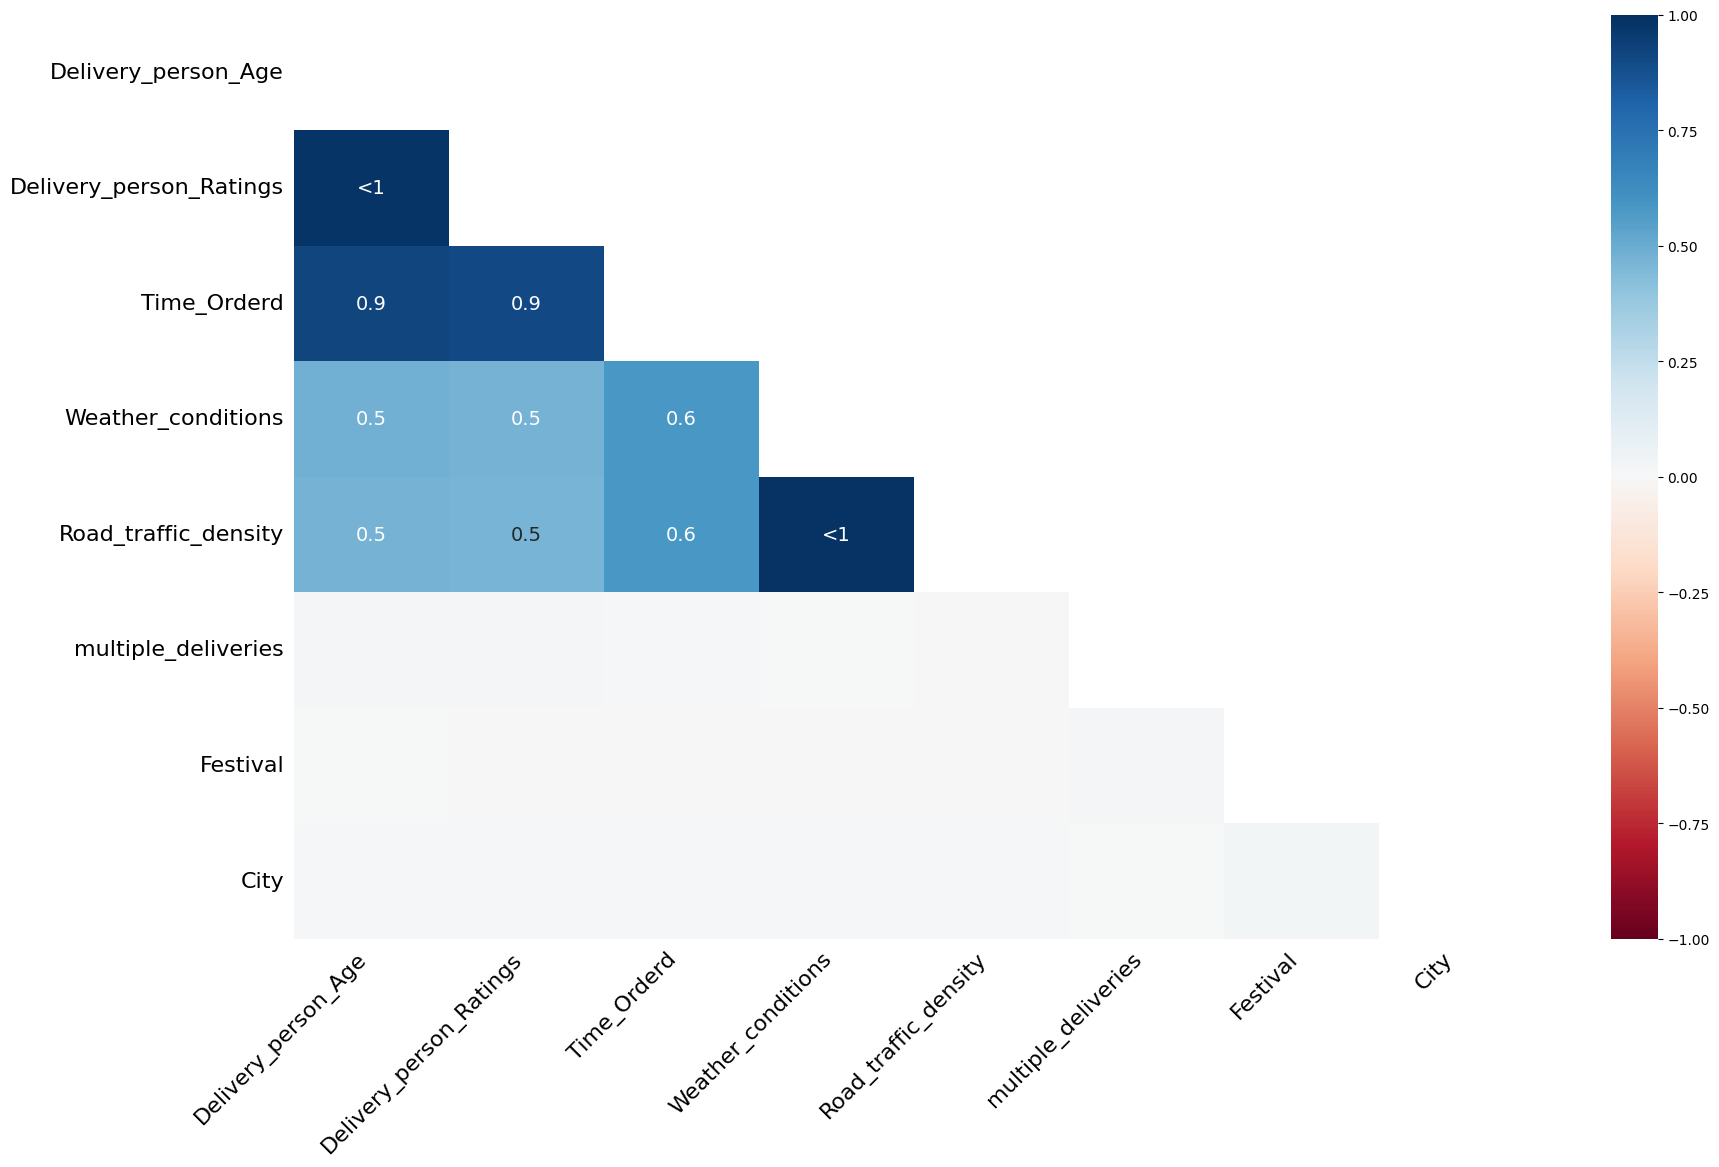

In [22]:
msno.heatmap(df_train)

<Axes: >

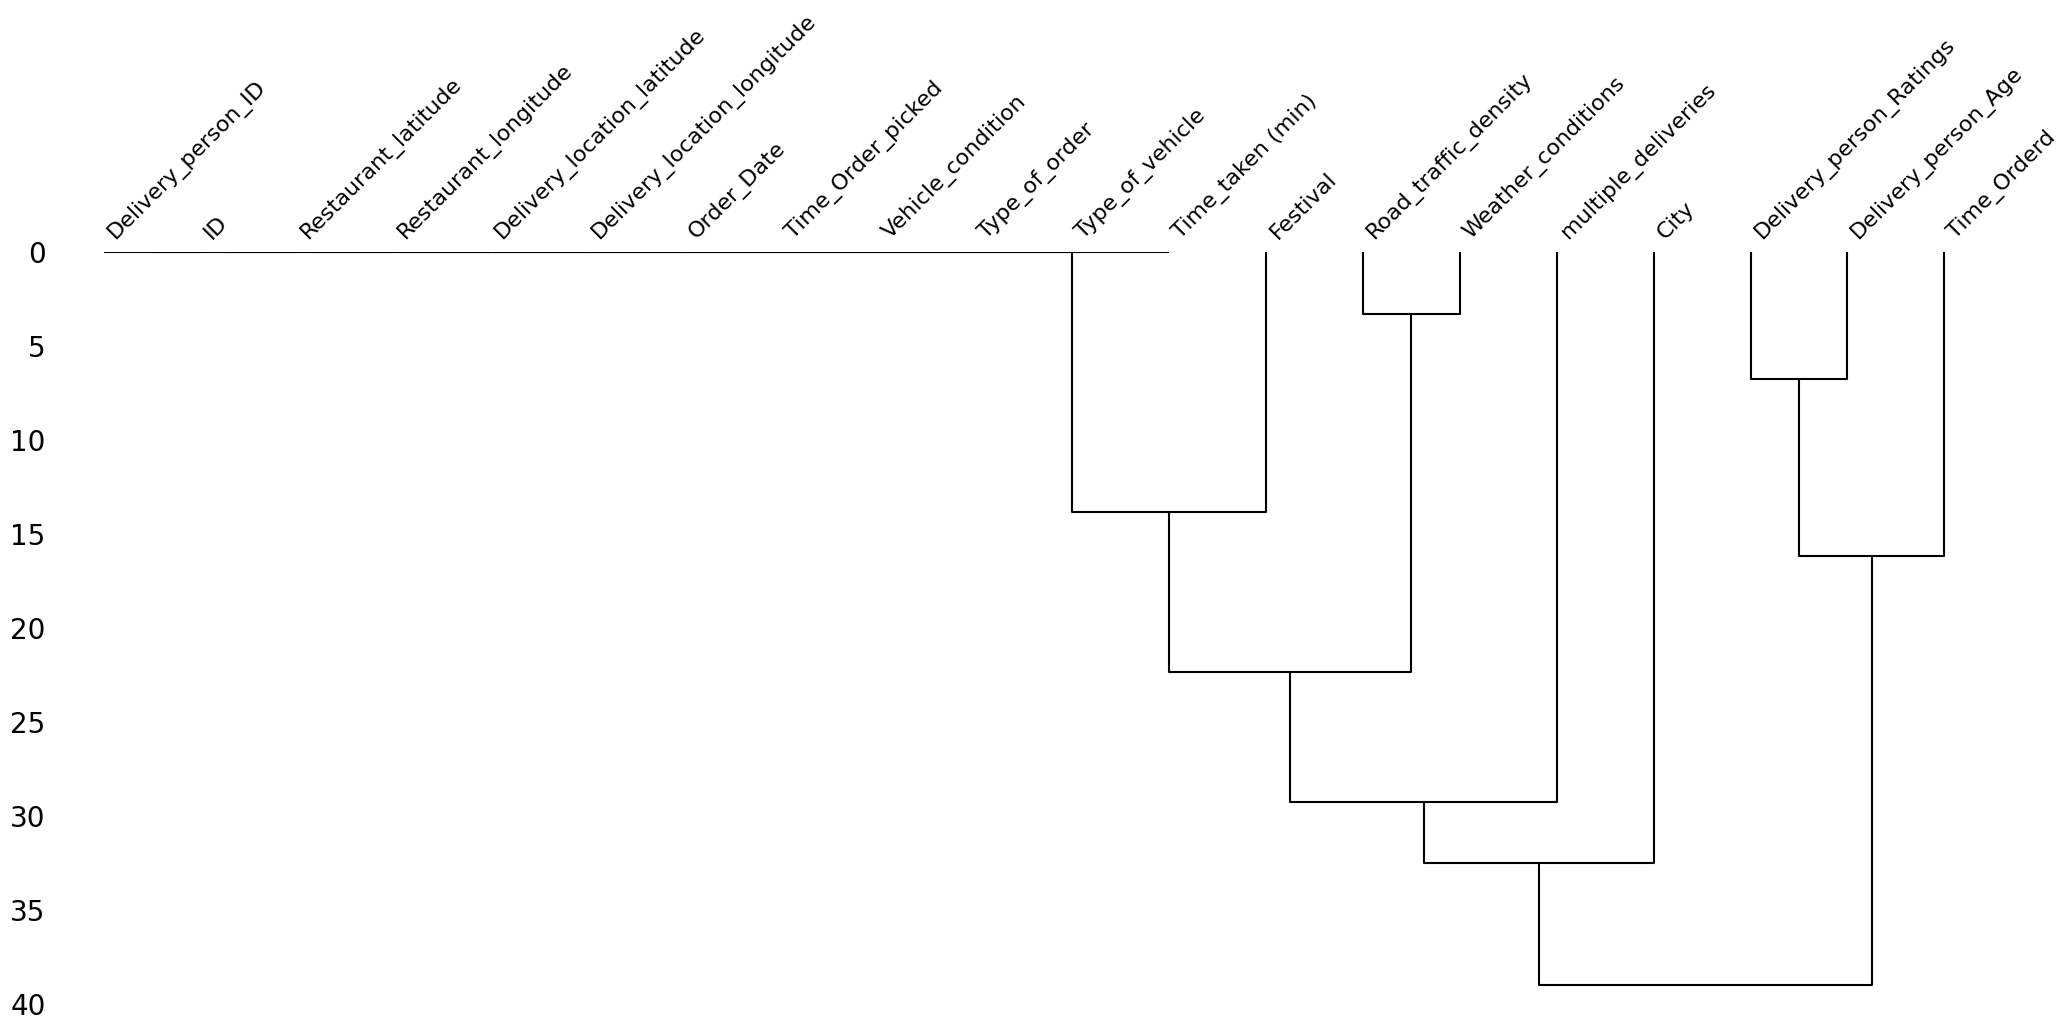

In [23]:
msno.dendrogram(df_train)

### Delivery Person ID

In [24]:
(
  df_train['Delivery_person_ID'].str.split("RES").str.get(0).rename("city_name")
)

0          INDO
1           MYS
2           MYS
3           SUR
4           VAD
          ...  
36462      CHEN
36463       JAP
36464    RANCHI
36465      INDO
36466       KOC
Name: city_name, Length: 36467, dtype: object

<Axes: ylabel='Delivery_person_Age'>

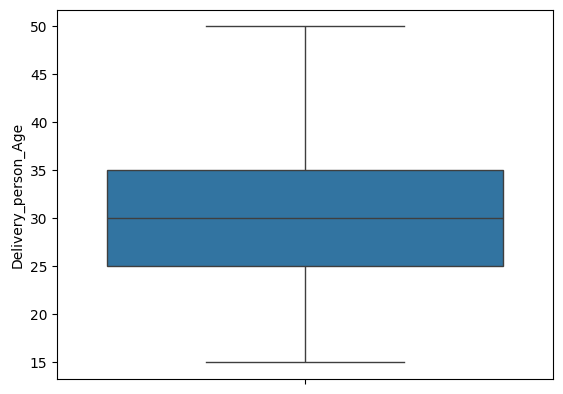

In [25]:
sns.boxplot(df_train['Delivery_person_Age'])

In [26]:
minor_age_del =df_train.loc[df_train['Delivery_person_Age'].astype('float') <  18]

In [27]:
minor_age_del

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
3705,0x2314,VADRES04DEL01,15.0,1.0,0.000000,0.000000,0.070000,0.070000,14-03-2022,NaN,17:40,NaN,NaN,3,Drinks,scooter,0.0,No,Metropolitian,34
5077,0x85c,COIMBRES17DEL02,15.0,1.0,11.026117,76.944652,11.046117,76.964652,09-03-2022,NaN,09:10,NaN,NaN,3,Snack,scooter,1.0,No,Metropolitian,19
8269,0xbb3,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.116286,80.365235,20-03-2022,NaN,22:50,NaN,NaN,3,Drinks,scooter,0.0,No,Metropolitian,27
8700,0x18b0,RANCHIRES02DEL01,15.0,1.0,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55,NaN,NaN,3,Meal,bicycle,1.0,No,Metropolitian,21
9846,0x49c,COIMBRES14DEL02,15.0,1.0,11.003681,76.975525,11.133681,77.105525,02-04-2022,NaN,23:45,NaN,NaN,3,Meal,scooter,0.0,No,Metropolitian,25
9915,0xe4c,MYSRES05DEL03,15.0,1.0,12.323978,76.627961,12.413978,76.717961,27-03-2022,NaN,0.833333333,NaN,NaN,3,Meal,electric_scooter,0.0,No,Urban,24
10147,0x40b,SURRES12DEL01,15.0,1.0,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30,NaN,NaN,3,Meal,scooter,1.0,No,Urban,27
10315,0x474,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50,NaN,NaN,3,Drinks,bicycle,1.0,No,Metropolitian,25
11778,0x451,HYDRES14DEL03,15.0,1.0,-17.426228,-78.407495,17.486228,78.467495,19-03-2022,NaN,19:05,NaN,NaN,3,Buffet,electric_scooter,1.0,No,Urban,30
15743,0x424,PUNERES20DEL02,15.0,1.0,-18.592718,-73.773572,18.672718,73.853572,16-03-2022,NaN,20:25,NaN,NaN,3,Buffet,scooter,1.0,No,Urban,30


In [28]:
minor_age_del.value_counts().sum()


np.int64(0)

In [29]:
minor_age_del['Type_of_vehicle'].value_counts()

Type_of_vehicle
scooter             11
electric_scooter    10
bicycle              4
motorcycle           3
Name: count, dtype: int64

### Delivery  Person Ratings

In [30]:
df_train['Delivery_person_Ratings'].describe()

count    34920.000000
mean         4.635049
std          0.331905
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

<Axes: ylabel='Delivery_person_Ratings'>

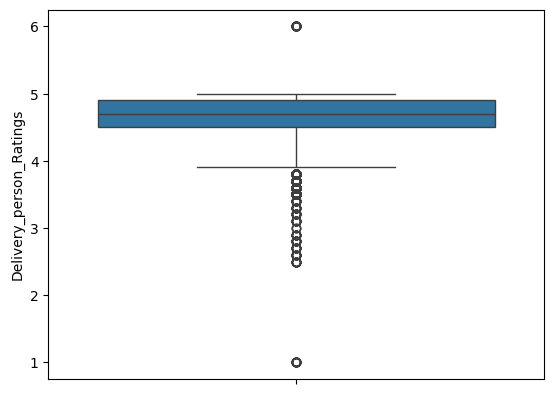

In [31]:
sns.boxplot(df_train['Delivery_person_Ratings'])

it seems that there is lot of error

lets find out those rows which has ratings of 6

In [32]:
six_star_rating = df_train.loc[df_train['Delivery_person_Ratings'] == 6]
print(len(six_star_rating))
six_star_rating

42


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
1937,0x421,CHENRES19DEL01,50.0,6.0,12.986047,80.218114,12.996047,80.228114,17-03-2022,NaN,09:35,NaN,NaN,3,Drinks,bicycle,0.0,No,Metropolitian,12
1979,0x420,SURRES13DEL01,50.0,6.0,-21.170096,-72.789122,21.180096,72.799122,15-03-2022,NaN,10:10,NaN,NaN,3,Meal,motorcycle,0.0,No,Metropolitian,17
2814,0x706,VADRES09DEL02,50.0,6.0,0.000000,0.000000,0.050000,0.050000,11-03-2022,NaN,22:30,NaN,NaN,3,Drinks,scooter,0.0,No,Metropolitian,28
2918,0x412,CHENRES010DEL01,50.0,6.0,-13.066762,-80.251865,13.076762,80.261865,17-03-2022,NaN,09:15,NaN,NaN,3,Drinks,electric_scooter,1.0,No,Metropolitian,20
4655,0x3ef,RANCHIRES13DEL01,50.0,6.0,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,17:55,NaN,NaN,3,Snack,bicycle,1.0,No,Metropolitian,32
5713,0xc363,BHPRES08DEL03,50.0,6.0,23.232537,77.429845,23.322537,77.519845,18-02-2022,NaN,21:25,NaN,NaN,3,Buffet,scooter,1.0,No,Metropolitian,17
6760,0x2950,VADRES04DEL02,50.0,6.0,0.000000,0.000000,0.020000,0.020000,19-03-2022,NaN,10:40,NaN,NaN,3,Drinks,electric_scooter,1.0,No,Urban,28
8047,0xbef1,AGRRES13DEL02,50.0,6.0,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,18:05,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,20
8605,0x3f6,MYSRES06DEL02,50.0,6.0,12.323994,76.626167,12.373994,76.676167,03-03-2022,NaN,21:25,NaN,NaN,3,Meal,scooter,0.0,No,Urban,15
9489,0xbf34,KNPRES16DEL02,50.0,6.0,26.482581,80.315628,26.612581,80.445628,12-02-2022,NaN,18:30,NaN,NaN,3,Buffet,scooter,1.0,No,Metropolitian,41


In [33]:
(df_train['Delivery_person_Ratings'] == 6).sum()

np.int64(42)

### key Observations

1. The delivery person columns are correlated to each other. This means that missingness in these columns is highly related which means lack of rider data.

2.The time ordered column is also related to the rider which shows that the data might be missing due to some network error where the system was unable to log rider details and time of order.

3.There is a very high correlation between weather patterns and the road traffic information. Be clear that this does not mean that the road traffic and weather columns are correlated. High corr in missingness means that if value in one column is missing, it is a high chance that it will be missing in others as well.

4.Road traffic density also shows correlation to the rider as it might be provided through the phone of rider (need to investigate)

In [34]:
missing_df[["Delivery_person_Age", "Delivery_person_Ratings"]].sum()

np.int64(3048)

In [35]:
(df_train.isna().any(axis=1).sum() / df_train.shape[0]) * 100

np.float64(9.296075904242192)

### Basic Data Cleaning

In [36]:
def change_column_names(data: pd.DataFrame):
    return (
        data.rename(str.lower, axis=1)
        .rename({
            "delivery_person_id" : "rider_id",
            "delivery_person_age" : "age",
            "delivery_person_ratings" : "ratings",
            "delivery_location_latitude" : "delivery_latitude",
            "delivery_location_longitude" : "delivery_longitude",
            "time_orderd" : "order_time",
            "time_order_picked" : "order_picked_time",
            "weatherconditions" : "weather",
            "road_traffic_density" : "traffic",
            "city" : "city_type",
            "time_taken(min)" : "time_taken"}, axis=1)
    )

### column wise cleaning

removing the **rider_id**

In [37]:

df_train = hf_dataset.to_pandas()
df_train = change_column_names(df_train)

df_train['city_name'] = df_train['rider_id'].str.split("RES").str.get(0)


df = df_train.drop(columns=["id"])
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name
0,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17,INDO
1,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33,MYS
2,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20,MYS
3,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27,SUR
4,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26,VAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36462,CHENRES12DEL01,39.0,4.7,12.972793,80.249982,13.042793,80.319982,02-03-2022,22:45,22:55,Stormy,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,27,CHEN
36463,JAPRES01DEL01,37.0,4.8,26.905190,75.810753,26.945190,75.850753,15-03-2022,15:50,0.666666667,Stormy,Medium,1,Buffet,scooter,0.0,No,Metropolitian,26,JAP
36464,RANCHIRES08DEL02,30.0,4.2,23.353783,85.326967,23.483783,85.456967,04-03-2022,21:15,21:20,Stormy,Jam,2,Drinks,scooter,2.0,No,Metropolitian,37,RANCHI
36465,INDORES08DEL03,NaN,NaN,-22.725748,75.898497,22.755747,75.928497,21-03-2022,NaN,22:05,Stormy,Jam,1,Buffet,scooter,1.0,No,Metropolitian,16,INDO


#### Age

In [38]:
df['age'].astype('float').describe()

count    34966.000000
mean        29.570840
std          5.806952
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

In [39]:
df_train.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,...,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,...,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17,INDO
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,...,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33,MYS
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,...,Windy,Low,2,Meal,scooter,0.0,No,NaN,20,MYS
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,...,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27,SUR
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,...,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26,VAD


df.head()

<Axes: ylabel='age'>

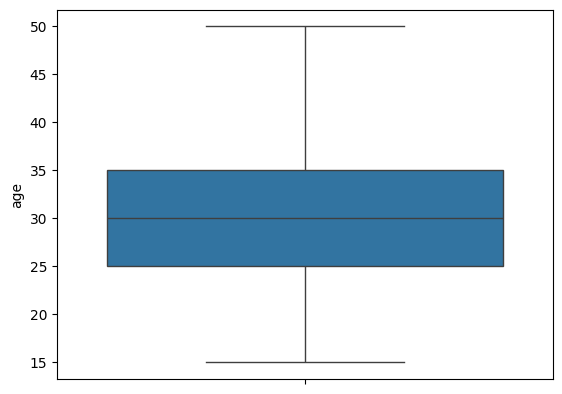

In [40]:
sns.boxplot(df['age'])


In [41]:
minor_age_del

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
3705,0x2314,VADRES04DEL01,15.0,1.0,0.000000,0.000000,0.070000,0.070000,14-03-2022,NaN,17:40,NaN,NaN,3,Drinks,scooter,0.0,No,Metropolitian,34
5077,0x85c,COIMBRES17DEL02,15.0,1.0,11.026117,76.944652,11.046117,76.964652,09-03-2022,NaN,09:10,NaN,NaN,3,Snack,scooter,1.0,No,Metropolitian,19
8269,0xbb3,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.116286,80.365235,20-03-2022,NaN,22:50,NaN,NaN,3,Drinks,scooter,0.0,No,Metropolitian,27
8700,0x18b0,RANCHIRES02DEL01,15.0,1.0,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55,NaN,NaN,3,Meal,bicycle,1.0,No,Metropolitian,21
9846,0x49c,COIMBRES14DEL02,15.0,1.0,11.003681,76.975525,11.133681,77.105525,02-04-2022,NaN,23:45,NaN,NaN,3,Meal,scooter,0.0,No,Metropolitian,25
9915,0xe4c,MYSRES05DEL03,15.0,1.0,12.323978,76.627961,12.413978,76.717961,27-03-2022,NaN,0.833333333,NaN,NaN,3,Meal,electric_scooter,0.0,No,Urban,24
10147,0x40b,SURRES12DEL01,15.0,1.0,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30,NaN,NaN,3,Meal,scooter,1.0,No,Urban,27
10315,0x474,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50,NaN,NaN,3,Drinks,bicycle,1.0,No,Metropolitian,25
11778,0x451,HYDRES14DEL03,15.0,1.0,-17.426228,-78.407495,17.486228,78.467495,19-03-2022,NaN,19:05,NaN,NaN,3,Buffet,electric_scooter,1.0,No,Urban,30
15743,0x424,PUNERES20DEL02,15.0,1.0,-18.592718,-73.773572,18.672718,73.853572,16-03-2022,NaN,20:25,NaN,NaN,3,Buffet,scooter,1.0,No,Urban,30


### Observations:

1. The star ratings of all the riders is 1.
2. Tile vehicle condition of these riders is very bad.
3. No weather and traffic conditions available.
4. Age of all these riders is 15 which is below the permissable age to drive a vehicle.
5. Latitude and Longitude values in negative which is not possible. India is situated above the equator so all latitudes should be positive and east of meridian line so longitudes are positive as well.

#### Seems like removing this data for now makes more sense then fixing it because a lot of data is missing.


In [42]:
minor_index = minor_age_del.index
len(minor_index)

28

In [43]:
df.shape

(36467, 20)

In [44]:
def data_cleaning(data:pd.DataFrame):
return 

IndentationError: expected an indented block after function definition on line 1 (41544515.py, line 2)

### Ratings

<Axes: ylabel='ratings'>

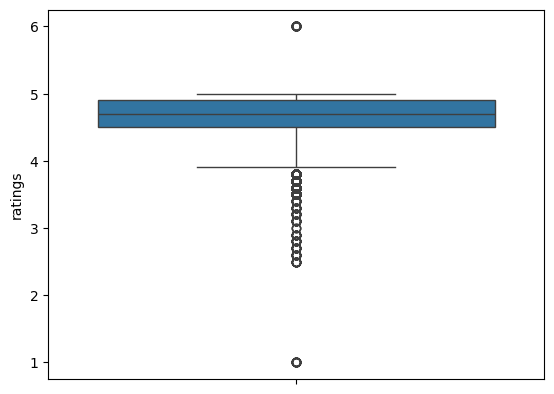

In [ ]:
sns.boxplot(df['ratings'])

In [ ]:
df['ratings'].describe()

count    34920.000000
mean         4.635049
std          0.331905
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

In [ ]:
df['ratings'].value_counts()


ratings
4.8    5771
4.7    5706
4.9    5652
4.6    5547
5.0    3154
4.5    2649
4.3    1147
4.2    1131
4.1    1106
4.4    1083
4.0     875
3.5     193
3.8     176
3.6     174
3.7     166
3.9     146
6.0      42
1.0      28
3.4      26
3.2      24
3.1      21
2.6      20
3.3      18
2.7      17
2.8      17
2.5      16
2.9      12
3.0       3
Name: count, dtype: int64

In [ ]:
six_star = df.loc[df['ratings'] == 6]
len(six_star)

42

In [ ]:
six_star_index = six_star.index.tolist()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 36397 entries, 0 to 36466
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              36397 non-null  str    
 1   age                   34896 non-null  float64
 2   ratings               34850 non-null  float64
 3   restaurant_latitude   36397 non-null  float64
 4   restaurant_longitude  36397 non-null  float64
 5   delivery_latitude     36397 non-null  float64
 6   delivery_longitude    36397 non-null  float64
 7   order_date            36397 non-null  str    
 8   order_time            35066 non-null  str    
 9   order_picked_time     36397 non-null  str    
 10  weather_conditions    35974 non-null  str    
 11  traffic               35985 non-null  str    
 12  vehicle_condition     36397 non-null  int64  
 13  type_of_order         36397 non-null  str    
 14  type_of_vehicle       36397 non-null  str    
 15  multiple_deliveries   35607 non-nul

In [ ]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name
0,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17,INDO
1,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33,MYS
2,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20,MYS
3,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27,SUR
4,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26,VAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36462,CHENRES12DEL01,39.0,4.7,12.972793,80.249982,13.042793,80.319982,02-03-2022,22:45,22:55,Stormy,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,27,CHEN
36463,JAPRES01DEL01,37.0,4.8,26.905190,75.810753,26.945190,75.850753,15-03-2022,15:50,0.666666667,Stormy,Medium,1,Buffet,scooter,0.0,No,Metropolitian,26,JAP
36464,RANCHIRES08DEL02,30.0,4.2,23.353783,85.326967,23.483783,85.456967,04-03-2022,21:15,21:20,Stormy,Jam,2,Drinks,scooter,2.0,No,Metropolitian,37,RANCHI
36465,INDORES08DEL03,NaN,NaN,-22.725748,75.898497,22.755747,75.928497,21-03-2022,NaN,22:05,Stormy,Jam,1,Buffet,scooter,1.0,No,Metropolitian,16,INDO


In [ ]:
def clean_data(data: pd.DataFrame):
  return (
    data
    .drop(index=minor_index, errors="ignore")
    .drop(index=six_star_index, errors="ignore")
    .replace("NaN", np.nan)
    .assign(
      city_name=lambda x: x["rider_id"].str.split("RES").str.get(0),
      age=lambda x: x["age"].astype("float"),
      ratings=lambda x: x["ratings"].astype("float"),
    )
  )
df['ratings'].describe()

count    34850.000000
mean         4.636324
std          0.312280
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

In [ ]:
df.loc[df['ratings'] == 6]

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name


finaly removed the 6 stars

### Locations

In [ ]:
location_columns = df.columns[3:8].tolist()
location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'order_date']

In [ ]:
location_subset = df.loc[:, location_columns]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date
0,22.651847,75.881991,22.721847,75.951991,18-03-2022
1,12.337978,76.616792,12.377978,76.656792,17-03-2022
2,12.325461,76.632278,12.375461,76.682278,03-03-2022
3,21.183434,72.814492,21.213434,72.844492,05-03-2022
4,22.310237,73.158921,22.360237,73.208921,11-03-2022
...,...,...,...,...,...
36462,12.972793,80.249982,13.042793,80.319982,02-03-2022
36463,26.905190,75.810753,26.945190,75.850753,15-03-2022
36464,23.353783,85.326967,23.483783,85.456967,04-03-2022
36465,-22.725748,75.898497,22.755747,75.928497,21-03-2022


valid values of latitude and longitude in **India**
is  north of the equator btw 6* 44' & 35* 30' and north latitude 68*7' and 97* 25' east longitude

In [ ]:
location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,36397.000000,36397.000000,36397.000000,36397.000000
mean,17.047987,70.336360,17.479542,70.871095
std,8.154540,22.610214,7.337368,21.088755
min,-30.902872,-88.352885,0.010000,0.010000
25%,12.933284,73.170283,12.989096,73.288921
50%,18.551440,75.898497,18.633934,76.003400
75%,22.728163,78.046106,22.785049,78.110267
max,30.914057,88.433452,31.054057,88.563452


here we can observe that the minimum latitudee and longitude of the restaurent and delivery is probably **wrong**

In [ ]:
lower_bound_latitude = 6.44
lower_bound_longitude = 68.70

In [ ]:
df.loc[
  (df['restaurant_latitude'] < lower_bound_latitude) | 
  (df['restaurant_longitude'] < lower_bound_longitude) |
  (df['delivery_latitude'] < lower_bound_latitude) |
  (df['delivery_longitude'] < lower_bound_longitude)
].sample(50)


,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name
28930,VADRES12DEL02,25.0,5.0,0.000000,0.000000,0.080000,0.080000,18-03-2022,21:15,21:20,Stormy,Jam,0,Meal,motorcycle,1.0,No,Urban,27,VAD
1942,RANCHIRES12DEL01,25.0,4.5,0.000000,0.000000,0.110000,0.110000,16-03-2022,21:10,21:15,Sandstorms,Jam,1,Meal,motorcycle,1.0,No,Metropolitian,26,RANCHI
5109,RANCHIRES03DEL03,27.0,4.1,0.000000,0.000000,0.090000,0.090000,02-03-2022,17:20,17:25,Cloudy,Medium,1,Snack,motorcycle,1.0,No,Metropolitian,36,RANCHI
19215,JAPRES06DEL02,NaN,NaN,-26.911927,75.797282,26.961927,75.847282,05-03-2022,NaN,20:50,Sandstorms,Jam,2,Meal,scooter,1.0,No,Metropolitian,27,JAP
13915,MYSRES12DEL01,NaN,NaN,-12.284747,-76.625861,12.324747,76.665861,13-03-2022,NaN,0.625,NaN,NaN,3,Buffet,motorcycle,1.0,No,Metropolitian,20,MYS
5597,RANCHIRES02DEL01,39.0,4.6,0.000000,0.000000,0.110000,0.110000,23-03-2022,17:20,17:35,Sandstorms,Medium,1,Meal,motorcycle,1.0,No,Metropolitian,30,RANCHI
24163,VADRES04DEL02,33.0,4.8,0.000000,0.000000,0.050000,0.050000,30-03-2022,17:35,17:40,Sandstorms,Medium,0,Drinks,motorcycle,1.0,No,Metropolitian,36,VAD
24810,AGRRES09DEL03,29.0,4.5,0.000000,0.000000,0.060000,0.060000,15-02-2022,22:10,22:25,Windy,Low,2,Drinks,motorcycle,1.0,No,NaN,12,AGR
30782,BHPRES14DEL02,25.0,4.6,0.000000,0.000000,0.130000,0.130000,16-02-2022,23:55,24:05:00,Sunny,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,21,BHP
34596,VADRES16DEL03,28.0,4.6,0.000000,0.000000,0.060000,0.060000,21-03-2022,22:25,22:30,Windy,Low,2,Drinks,motorcycle,1.0,No,Metropolitian,15,VAD


In [ ]:
location_subset.loc[
  (location_subset['restaurant_latitude'] < lower_bound_latitude) |
  (location_subset['restaurant_longitude'] < lower_bound_longitude) | 
  (location_subset['delivery_latitude'] < lower_bound_latitude) |
  (location_subset['delivery_longitude'] < lower_bound_longitude)
].shape[0]

3225

there are **3225** data latitude and longitude data are **messy data**

In [ ]:
location_subset.loc[
  (location_subset['restaurant_latitude'] < lower_bound_latitude) |
  (location_subset['restaurant_longitude'] < lower_bound_longitude) | 
  (location_subset['delivery_latitude'] < lower_bound_latitude) |
  (location_subset['delivery_longitude'] < lower_bound_longitude)
].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,3225.000000,3225.000000,3225.000000,3225.000000
mean,-2.076093,2.615280,2.139160,7.995006
std,6.442308,24.737862,6.442130,23.576561
min,-30.902872,-88.352885,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.030184,88.523452


<Axes: >

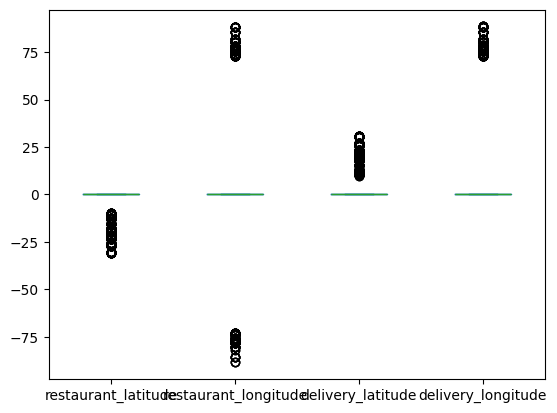

In [ ]:
location_subset.loc[
  (location_subset['restaurant_latitude'] < lower_bound_latitude) |
  (location_subset['restaurant_longitude'] < lower_bound_longitude) | 
  (location_subset['delivery_latitude'] < lower_bound_latitude) |
  (location_subset['delivery_longitude'] < lower_bound_longitude)
].plot(kind="box")

here for the negative values can be corrected using the **absolute value**

while calculating the distance we can assign null values to these errorness and data points then  impute the values usinng advanced impuatation techniques

In [ ]:
# Force all location columns to be float data types
df['restaurant_latitude'] = df['restaurant_latitude'].astype(float)
df['restaurant_longitude'] = df['restaurant_longitude'].astype(float)
df['delivery_latitude'] = df['delivery_latitude'].astype(float)
df['delivery_longitude'] = df['delivery_longitude'].astype(float)

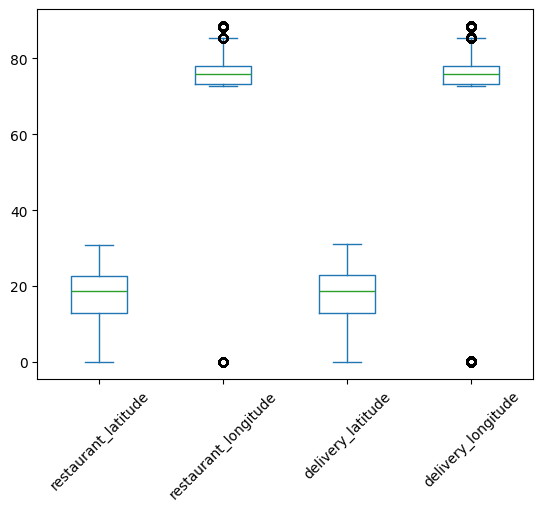

In [ ]:
# Re-isolate your location columns now that they are numbers
location_subset = df[['restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude']]

# This will now work flawlessly without throwing the Arrow error!
location_subset.abs().plot(kind="box")

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

the negative  values got resolved

In [ ]:
(
  location_subset.abs()
  .loc[lambda df_:
      (df_['restaurant_latitude'] < lower_bound_latitude) | 
      (df_['restaurant_longitude'] < lower_bound_longitude) |
      (df_['delivery_latitude'] < lower_bound_latitude) |
      (df_['delivery_longitude'] < lower_bound_longitude)]
  .shape[0]
)

2896

now it reduced from **3225** to **2896**

In [ ]:
(
  location_subset.abs()
  .loc[lambda df_:
      (df_['restaurant_latitude'] < 1) | 
      (df_['restaurant_longitude'] < 1) |
      (df_['delivery_latitude'] < 1) |
      (df_['delivery_longitude'] < 1)]
)

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
11,0.0,0.0,0.08,0.08
12,0.0,0.0,0.04,0.04
30,0.0,0.0,0.01,0.01
83,0.0,0.0,0.02,0.02
106,0.0,0.0,0.09,0.09
...,...,...,...,...
36430,0.0,0.0,0.06,0.06
36431,0.0,0.0,0.11,0.11
36436,0.0,0.0,0.09,0.09
36454,0.0,0.0,0.08,0.08


all theese messy data  are less than 1

In [ ]:
def clean_lat_long(data: pd.DataFrame, threshold=1):
    location_columns = location_subset.columns.tolist()
    
    return (
        data
        .assign(**{
            col: (
                np.where(data[col] < threshold, np.nan, data[col].values)
            )
            for col in location_columns
        })
    )

In [ ]:
clean_lat_long(df).isna().sum()

rider_id                   0
age                     1501
ratings                 1547
restaurant_latitude     3225
restaurant_longitude    3007
delivery_latitude       2896
delivery_longitude      2896
order_date                 0
order_time              1331
order_picked_time          0
weather_conditions       423
traffic                  412
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      790
festival                 192
city_type                955
time_taken (min)           0
city_name                  0
dtype: int64

In [ ]:
def clean_data(data:pd.DataFrame):
    return(      
        data
        #.drop(index=minor_index)
        .drop(index=six_star_index)
        .replace("NaN", np.nan)
        .assign(
            city_name = lambda x: x["rider_id"].str.split("RES").str.get(0),
            #convert age and  ratings to float
            age = lambda x: x["age"].astype('float'),
            ratings = lambda x: x["ratings"].astype('float'),
            # al these  columns to be absolute values so that we can easily identify the outliers
            restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
            restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
            delivery_latitude = lambda x: x['delivery_latitude'].abs(),
            delivery_longitude = lambda x: x['delivery_longitude'].abs(),
            order_day = lambda x: x['order_date'].dt.day,
            order_month = lambda x: x['order_date'].dt.month,
            order_year = lambda x: x['order_date'].dt.year,
            order_day_of_week = lambda x: x['order_date'].dt.day_name().str.lower(),
            is_weekend = lambda x: x['order_date'].dt.dayname().str.lower().isin(['saturday', 'sunday']).astype(int),
        )
    )



In [ ]:
clean_data(df)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name
0,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17,INDO
1,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33,MYS
2,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20,MYS
3,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27,SUR
4,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26,VAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36462,CHENRES12DEL01,39.0,4.7,12.972793,80.249982,13.042793,80.319982,02-03-2022,22:45,22:55,Stormy,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,27,CHEN
36463,JAPRES01DEL01,37.0,4.8,26.905190,75.810753,26.945190,75.850753,15-03-2022,15:50,0.666666667,Stormy,Medium,1,Buffet,scooter,0.0,No,Metropolitian,26,JAP
36464,RANCHIRES08DEL02,30.0,4.2,23.353783,85.326967,23.483783,85.456967,04-03-2022,21:15,21:20,Stormy,Jam,2,Drinks,scooter,2.0,No,Metropolitian,37,RANCHI
36465,INDORES08DEL03,NaN,NaN,22.725748,75.898497,22.755747,75.928497,21-03-2022,NaN,22:05,Stormy,Jam,1,Buffet,scooter,1.0,No,Metropolitian,16,INDO


In [ ]:
location_subset.columns.tolist()

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

### order date

In [ ]:
df['order_date'].isna().sum()

np.int64(0)

In [ ]:
df['order_date'].describe()

count          36397
unique            44
top       03-04-2022
freq             956
Name: order_date, dtype: object

date range

In [ ]:
order_date = pd.to_datetime(df['order_date'], dayfirst=True)
order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

min and max dates

In [ ]:

order_date.agg(['min', 'max']).set_axis(['start', 'end'],axis=0)

start   2022-02-11
end     2022-04-06
Name: order_date, dtype: datetime64[us]

extract the day month and year from the date

In [ ]:
# extract day, day name, month and year

def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser, dayfirst=True)

    return (
        pd.DataFrame(
            {
                "day": date_col.dt.day,
                "month": date_col.dt.month,
                "year": date_col.dt.year,
                "day_of_week": date_col.dt.day_name(),
                "is_weekend": date_col.dt.day_name().isin(["Saturday", "Sunday"]).astype(int)
            }
        )
    )

In [ ]:
extract_datetime_features(df['order_date'])

,day,month,year,day_of_week,is_weekend
0,18,3,2022,Friday,0
1,17,3,2022,Thursday,0
2,3,3,2022,Thursday,0
3,5,3,2022,Saturday,1
4,11,3,2022,Friday,0
...,...,...,...,...,...
36462,2,3,2022,Wednesday,0
36463,15,3,2022,Tuesday,0
36464,4,3,2022,Friday,0
36465,21,3,2022,Monday,0


In [ ]:
def clean_data(data:pd.DataFrame):
  return(      
    data
    .drop(index=six_star_index)
    .replace("NaN", np.nan)
    .assign(
      city_name = lambda x: x["rider_id"].str.split("RES").str.get(0),
      age = lambda x: x["age"].astype('float'),
      ratings = lambda x: x["ratings"].astype('float'),
      restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
      restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
      delivery_latitude = lambda x: x['delivery_latitude'].abs(),
      delivery_longitude = lambda x: x['delivery_longitude'].abs(),
      order_date = lambda x: pd.to_datetime(x['order_date'], dayfirst=True),
      order_day = lambda x: pd.to_datetime(x['order_date'], dayfirst=True).dt.day,
      order_month = lambda x: pd.to_datetime(x['order_date'], dayfirst=True).dt.month,
      order_year = lambda x: pd.to_datetime(x['order_date'], dayfirst=True).dt.year,
      order_day_of_week = lambda x: pd.to_datetime(x['order_date'], dayfirst=True).dt.day_name().str.lower(),
      is_weekend = lambda x: pd.to_datetime(x['order_date'], dayfirst=True).dt.day_name().isin(['Saturday', 'Sunday']).astype(int),
    )
  )

###

### order time and placed time

In [ ]:
def _parse_hour(val):
  if pd.isna(val):
    return np.nan
  s = str(val).strip()
  # numeric values (fractions of day or hours)
  try:
    f = float(s)
    if 0 <= f <= 1:
      return int(f * 24) % 24
    if 1 <= f < 24:
      return int(f) % 24
  except Exception:
    pass
  # HH:MM or HH:MM:SS
  if ":" in s:
    try:
      h = int(s.split(":")[0])
      return 0 if h == 24 else h
    except Exception:
      pass
  # fallback to pandas parsing
  dt = pd.to_datetime(s, errors="coerce")
  if pd.isna(dt):
    return np.nan
  return 0 if dt.hour == 24 else dt.hour

order_time_hr = df['order_time'].apply(_parse_hour)

In [ ]:
order_time_hr

0        22.0
1        15.0
2        23.0
3        17.0
4        21.0
         ... 
36462    22.0
36463    15.0
36464    21.0
36465     NaN
36466    11.0
Name: order_time, Length: 36467, dtype: float64

to calculate the time of the day

In [ ]:
def time_of_day(ser):
    time_col = pd.to_datetime(ser, format='mixed').dt.hour

    return (
        np.select(
            condlist=[
                (ser.between(0, 12, inclusive='left')),
                (ser.between(12, 17, inclusive='left')),
                (ser.between(17, 20, inclusive='left')),
                (ser.between(20, 24, inclusive='left'))
            ],
            choicelist=["morning", "afternoon", "evening", "night"],
            default="after_midnight"
        )
    )

In [ ]:
time_subset = df.loc[:, ['order_time', 'order_picked_time']]
time_subset

,order_time,order_picked_time
0,22:10,22:25
1,15:10,15:20
2,23:55,24:10:00
3,17:35,17:40
4,21:30,21:45
...,...,...
36462,22:45,22:55
36463,15:50,0.666666667
36464,21:15,21:20
36465,NaN,22:05


In [ ]:
time_subset.columns.tolist()

['order_time', 'order_picked_time']

In [ ]:
# calculate the pickup time

# calculate the pickup time

def _parse_time_entry(val):
  if pd.isna(val):
    return pd.NaT
  s = str(val).strip()
  # numeric (fractions of day or hour numbers)
  try:
    f = float(s)
    if 0 <= f <= 1:
      return pd.to_timedelta(f * 24 * 3600, unit="s")
    if 1 <= f < 24:
      return pd.to_timedelta(f * 3600, unit="s")
  except Exception:
    pass
  # HH:MM[:SS]
  if ":" in s:
    parts = s.split(":")
    try:
      h = int(parts[0])
      m = int(parts[1]) if len(parts) > 1 else 0
      sec = int(float(parts[2])) if len(parts) > 2 else 0
      # treat 24:xx as next-day 00:xx
      if h == 24:
        h = 0
      return pd.to_timedelta(hours=h, minutes=m, seconds=sec)
    except Exception:
      pass
  # fallback to pandas parsing
  try:
    td = pd.to_timedelta(s)
    return td
  except Exception:
    try:
      dt = pd.to_datetime(s, errors="coerce")
      if pd.isna(dt):
        return pd.NaT
      t = dt.time()
      return (pd.to_timedelta(t.hour, unit="h")
          + pd.to_timedelta(t.minute, unit="m")
          + pd.to_timedelta(t.second, unit="s"))
    except Exception:
      return pd.NaT

parsed = time_subset.map(_parse_time_entry)

pickup_delta = parsed["order_picked_time"] - parsed["order_time"]
# fix negative deltas (crossed midnight)
neg_mask = pickup_delta.dt.total_seconds() < 0
if neg_mask.any():
  pickup_delta.loc[neg_mask] = pickup_delta.loc[neg_mask] + pd.Timedelta(days=1)

result = (
  parsed
  .assign(
    pickup_time=lambda x: pickup_delta.dt.total_seconds() / 60,
    order_time_hour=lambda x: x["order_time"].dt.total_seconds() / 3600
  )
)

# categorize time of day
hour = result["order_time_hour"]
result["order_time_of_day"] = np.select(
  condlist=[
    hour.between(0, 12, inclusive="left"),
    hour.between(12, 17, inclusive="left"),
    hour.between(17, 20, inclusive="left"),
    hour.between(20, 24, inclusive="left")
  ],
  choicelist=["morning", "afternoon", "evening", "night"],
  default="after_midnight"
)

# drop raw columns and show
result.drop(columns=["order_time", "order_picked_time"])


,pickup_time,order_time_hour,order_time_of_day
0,15.0,22.166667,night
1,10.0,15.166667,afternoon
2,15.0,23.916667,night
3,5.0,17.583333,evening
4,15.0,21.500000,night
...,...,...,...
36462,10.0,22.750000,night
36463,10.0,15.833333,afternoon
36464,5.0,21.250000,night
36465,NaN,NaN,after_midnight


#### Categorical  columns
### Weather

In [ ]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather_conditions',
       'traffic', 'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken (min)',
       'city_name'],
      dtype='str')

no **NaN** values hence ignore

In [ ]:
'''
#if it would have exist then
weather = lambda x: x['weather_conditions'].str.lower().str.replace("conditions","").replace("NaN",np.nan)
'''

### traffic

In [45]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather_conditions,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken (min),city_name
0,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17,INDO
1,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33,MYS
2,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20,MYS
3,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27,SUR
4,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26,VAD


In [46]:
df['traffic'].nunique()

4

In [47]:
df['traffic'].value_counts()

traffic
Low       12358
Jam       11249
Medium     8843
High       3535
Name: count, dtype: int64

no  missing values

### vehicle connditions

In [49]:
df['vehicle_condition'].value_counts()

vehicle_condition
2    12054
0    12020
1    11981
3      412
Name: count, dtype: int64

### order type

In [50]:
df['type_of_order'].value_counts()

type_of_order
Snack     9234
Meal      9145
Buffet    9056
Drinks    9032
Name: count, dtype: int64

In [52]:
df['type_of_order'].unique()

<ArrowStringArray>
['Buffet', 'Meal', 'Snack', 'Drinks']
Length: 4, dtype: str

In [53]:
df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle          21127
scooter             12211
electric_scooter     3079
bicycle                50
Name: count, dtype: int64

In [54]:
df['multiple_deliveries'].value_counts()

multiple_deliveries
1.0    22528
0.0    11282
2.0     1581
3.0      286
Name: count, dtype: int64

In [55]:
df['festival'].value_counts()

festival
No     35552
Yes      723
Name: count, dtype: int64

In [56]:
df['city_type'].value_counts() 

city_type
Metropolitian    27241
Urban             8147
Semi-Urban         122
Name: count, dtype: int64

In [57]:
df['city_name'].value_counts() 


city_name
JAP       2751
RANCHI    2574
VAD       2568
BANG      2568
HYD       2557
COIMB     2530
MYS       2528
INDO      2527
MUM       2520
PUNE      2516
SUR       2513
CHEN      2500
LUDH       612
AGR        608
DEH        605
ALH        599
KNP        599
KOC        577
KOL        567
AURG       562
GOA        553
BHP        533
Name: count, dtype: int64

In [59]:
df['time_taken (min)'].describe()

count    36467.000000
mean        26.293772
std          9.384628
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time_taken (min), dtype: float64

In [60]:
df['time_taken (min)'].value_counts()

time_taken (min)
26    1721
25    1671
27    1607
29    1584
28    1548
15    1443
19    1433
18    1396
16    1357
17    1353
24    1352
23    1328
22    1318
20    1297
21    1285
33     996
31     975
30     967
34     929
32     894
38     697
36     674
39     673
35     670
37     634
11     618
10     612
12     596
14     591
13     554
41     462
42     451
44     450
43     446
40     440
47     234
49     227
48     219
46     218
45     190
54      83
53      78
51      76
52      63
50      57
Name: count, dtype: int64

In [ ]:
df = (
  df['time_taken (min)'].str.replace("")
)